In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv("C:\\Users\\rohin\\Sucide Project\\Merged data\\final_model_dataset_2000_onward.csv")
df.head()

,Year,AlcoholConsumption,HomicideRate,GDP_per_capita,Current health expenditure (% of GDP)_x,Current health expenditure per capita (current US$)_x,"Unemployment, total (% of total labor force) (modeled ILO estimate)_x",Current health expenditure (% of GDP)_y,Current health expenditure per capita (current US$)_y,"Unemployment, total (% of total labor force) (modeled ILO estimate)_y",SuicideRate,SuicideRate_Lower,SuicideRate_Upper
0,2000,8.742056,45.012212,3217.846934,7.336619,236.081146,22.714,7.336619,236.081146,22.714,13.132524,10.616174,15.492517
1,2001,8.742056,45.090413,2847.151919,7.123279,202.810654,22.605,7.123279,202.810654,22.605,13.245669,10.820065,15.693809
2,2002,8.483838,47.472567,2688.236760,6.677745,179.513550,22.547,6.677745,179.513550,22.547,14.598869,11.962040,17.234773
3,2003,8.366666,44.799503,4062.217560,7.040982,286.019989,22.629,7.040982,286.019989,22.629,15.759870,12.819716,18.513331
4,2004,8.343871,44.530240,5221.463337,6.938416,362.286621,22.538,6.938416,362.286621,22.538,16.074981,13.053871,18.851862


In [3]:
df.shape
df.columns

Index(['Year', 'AlcoholConsumption', 'HomicideRate', 'GDP_per_capita',
       'Current health expenditure (% of GDP)_x',
       'Current health expenditure per capita (current US$)_x',
       'Unemployment, total (% of total labor force) (modeled ILO estimate)_x',
       'Current health expenditure (% of GDP)_y',
       'Current health expenditure per capita (current US$)_y',
       'Unemployment, total (% of total labor force) (modeled ILO estimate)_y',
       'SuicideRate', 'SuicideRate_Lower', 'SuicideRate_Upper'],
      dtype='object')

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 13 columns):
 #   Column                                                                 Non-Null Count  Dtype  
---  ------                                                                 --------------  -----  
 0   Year                                                                   25 non-null     int64  
 1   AlcoholConsumption                                                     21 non-null     float64
 2   HomicideRate                                                           22 non-null     float64
 3   GDP_per_capita                                                         23 non-null     float64
 4   Current health expenditure (% of GDP)_x                                23 non-null     float64
 5   Current health expenditure per capita (current US$)_x                  23 non-null     float64
 6   Unemployment, total (% of total labor force) (modeled ILO estimate)_x  25 non-null     float

In [5]:
df.isna().sum()

Year                                                                     0
AlcoholConsumption                                                       4
HomicideRate                                                             3
GDP_per_capita                                                           2
Current health expenditure (% of GDP)_x                                  2
Current health expenditure per capita (current US$)_x                    2
Unemployment, total (% of total labor force) (modeled ILO estimate)_x    0
Current health expenditure (% of GDP)_y                                  2
Current health expenditure per capita (current US$)_y                    2
Unemployment, total (% of total labor force) (modeled ILO estimate)_y    0
SuicideRate                                                              3
SuicideRate_Lower                                                        3
SuicideRate_Upper                                                        3
dtype: int64

In [6]:
cols = df.columns.tolist()
pairs = []

for c in cols:
    if c.endswith("_x"):
        base = c[:-2]      # remove "_x"
        cy = base + "_y"   # expected pair
        if cy in cols:
            pairs.append((base, c, cy))

pairs

[('Current health expenditure (% of GDP)',
  'Current health expenditure (% of GDP)_x',
  'Current health expenditure (% of GDP)_y'),
 ('Current health expenditure per capita (current US$)',
  'Current health expenditure per capita (current US$)_x',
  'Current health expenditure per capita (current US$)_y'),
 ('Unemployment, total (% of total labor force) (modeled ILO estimate)',
  'Unemployment, total (% of total labor force) (modeled ILO estimate)_x',
  'Unemployment, total (% of total labor force) (modeled ILO estimate)_y')]

In [7]:
df_clean = df.copy()

for base, cx, cy in pairs:
    a = df[cx].values
    b = df[cy].values

    # Compare values
    identical = np.allclose(a, b, equal_nan=True)

    if identical:
        print(f"{cx} and {cy} are identical → keeping {cx}, dropping {cy}")
        df_clean.drop(columns=[cy], inplace=True)
    else:
        print(f"{cx} and {cy} differ → averaging into {base}")
        df_clean[base] = np.nanmean(np.vstack([a, b]), axis=0)
        df_clean.drop(columns=[cx, cy], inplace=True)


Current health expenditure (% of GDP)_x and Current health expenditure (% of GDP)_y are identical → keeping Current health expenditure (% of GDP)_x, dropping Current health expenditure (% of GDP)_y
Current health expenditure per capita (current US$)_x and Current health expenditure per capita (current US$)_y are identical → keeping Current health expenditure per capita (current US$)_x, dropping Current health expenditure per capita (current US$)_y
Unemployment, total (% of total labor force) (modeled ILO estimate)_x and Unemployment, total (% of total labor force) (modeled ILO estimate)_y are identical → keeping Unemployment, total (% of total labor force) (modeled ILO estimate)_x, dropping Unemployment, total (% of total labor force) (modeled ILO estimate)_y


In [8]:
df = df_clean.copy()
df.info()
df.isna().sum()
df.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 25 entries, 0 to 24
Data columns (total 10 columns):
 #   Column                                                                 Non-Null Count  Dtype  
---  ------                                                                 --------------  -----  
 0   Year                                                                   25 non-null     int64  
 1   AlcoholConsumption                                                     21 non-null     float64
 2   HomicideRate                                                           22 non-null     float64
 3   GDP_per_capita                                                         23 non-null     float64
 4   Current health expenditure (% of GDP)_x                                23 non-null     float64
 5   Current health expenditure per capita (current US$)_x                  23 non-null     float64
 6   Unemployment, total (% of total labor force) (modeled ILO estimate)_x  25 non-null     float

,Year,AlcoholConsumption,HomicideRate,GDP_per_capita,Current health expenditure (% of GDP)_x,Current health expenditure per capita (current US$)_x,"Unemployment, total (% of total labor force) (modeled ILO estimate)_x",SuicideRate,SuicideRate_Lower,SuicideRate_Upper
0,2000,8.742056,45.012212,3217.846934,7.336619,236.081146,22.714,13.132524,10.616174,15.492517
1,2001,8.742056,45.090413,2847.151919,7.123279,202.810654,22.605,13.245669,10.820065,15.693809
2,2002,8.483838,47.472567,2688.236760,6.677745,179.513550,22.547,14.598869,11.962040,17.234773
3,2003,8.366666,44.799503,4062.217560,7.040982,286.019989,22.629,15.759870,12.819716,18.513331
4,2004,8.343871,44.530240,5221.463337,6.938416,362.286621,22.538,16.074981,13.053871,18.851862


In [9]:
df.describe()

,Year,AlcoholConsumption,HomicideRate,GDP_per_capita,Current health expenditure (% of GDP)_x,Current health expenditure per capita (current US$)_x,"Unemployment, total (% of total labor force) (modeled ILO estimate)_x",SuicideRate,SuicideRate_Lower,SuicideRate_Upper
count,25.000000,21.000000,22.000000,23.000000,23.000000,23.000000,25.000000,22.000000,22.000000,22.000000
mean,2012.000000,8.351215,21.613153,6033.239153,7.703134,469.452724,25.815480,17.635772,14.350162,21.021674
std,7.359801,0.246938,13.300020,1567.531538,0.667647,139.596294,3.813187,2.496345,1.950624,3.210743
min,2000.000000,7.791870,12.533244,2688.236760,6.677745,179.513550,22.287000,13.132524,10.616174,15.492517
25%,2006.000000,8.336959,13.519279,5615.904841,7.082130,409.223663,22.605000,15.989385,13.006150,18.643192
50%,2012.000000,8.402676,14.372228,6374.705600,7.871366,491.906525,24.683000,17.737640,14.682823,21.023099
75%,2018.000000,8.451979,18.657802,6850.065395,8.080780,564.321075,27.035000,19.476279,15.934281,23.822539
max,2024.000000,8.742056,47.472567,8646.055711,9.013292,686.872437,34.007000,22.295801,17.174630,26.523387


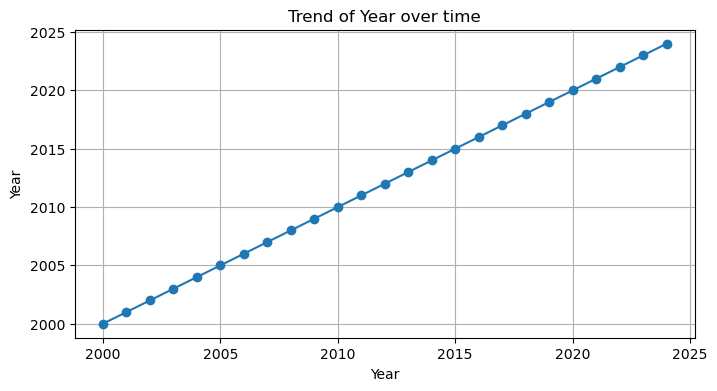

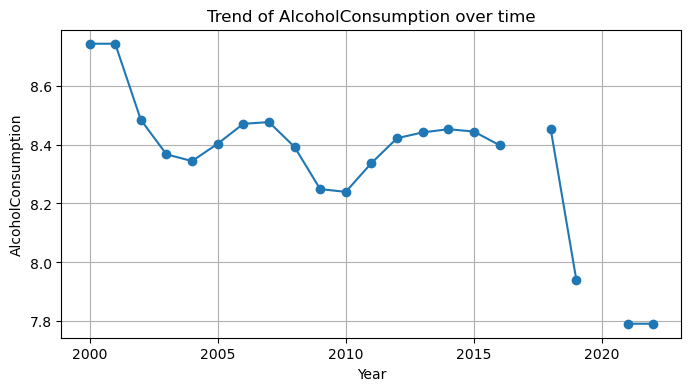

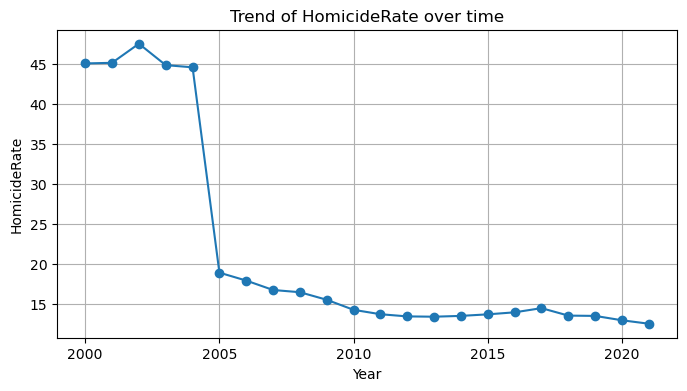

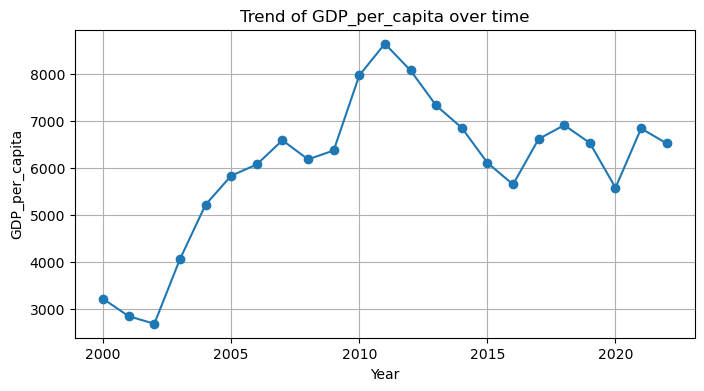

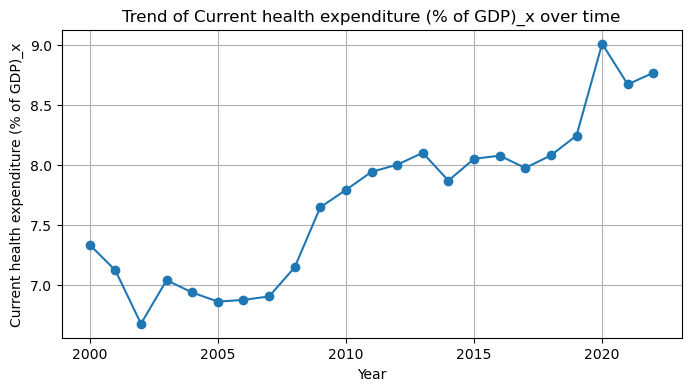

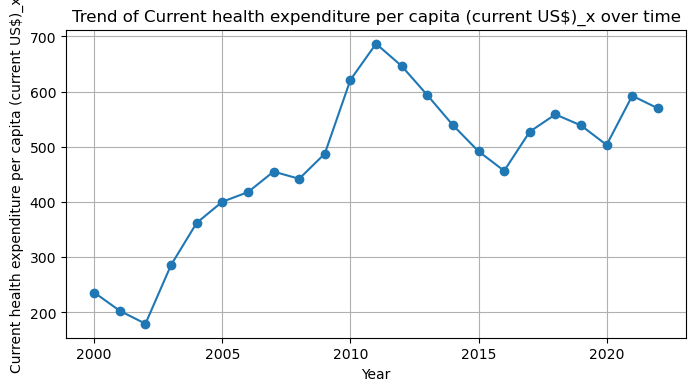

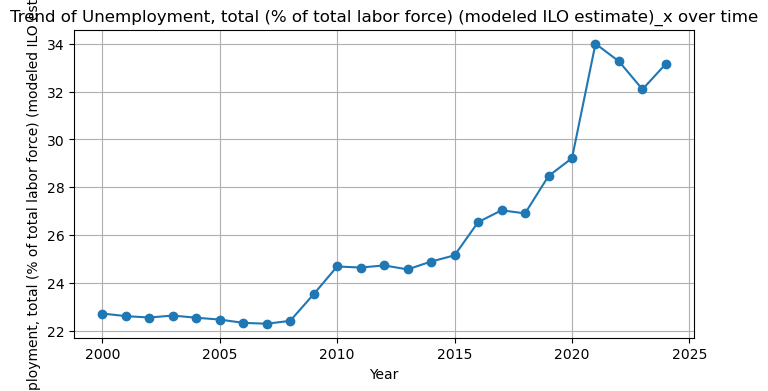

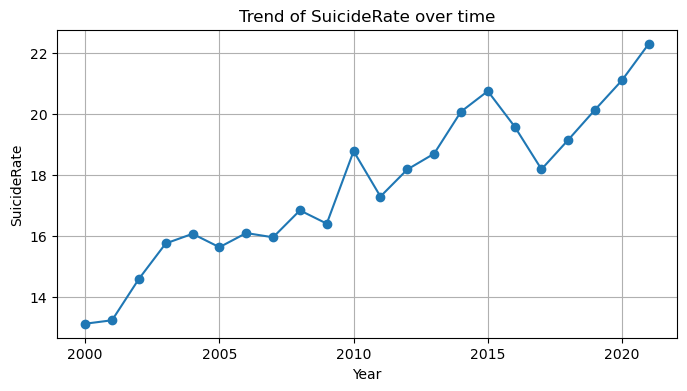

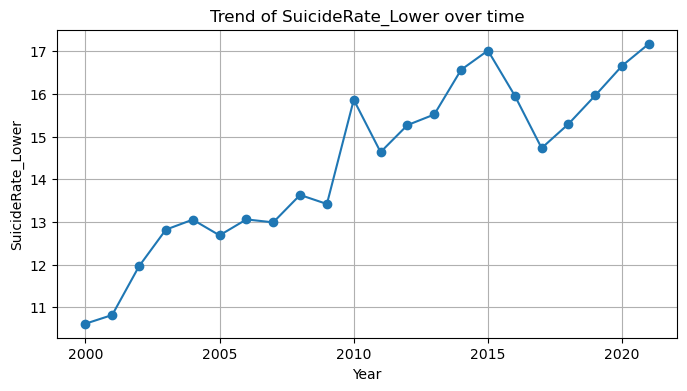

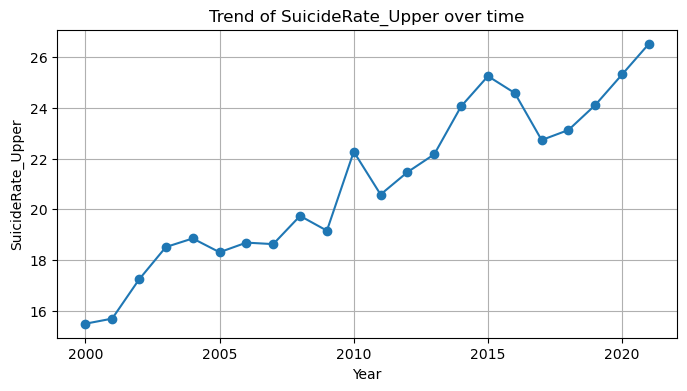

In [10]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

for col in numeric_cols:
    plt.figure(figsize=(8,4))
    plt.plot(df["Year"], df[col], marker="o")
    plt.title(f"Trend of {col} over time")
    plt.xlabel("Year")
    plt.ylabel(col)
    plt.grid(True)
    plt.show()

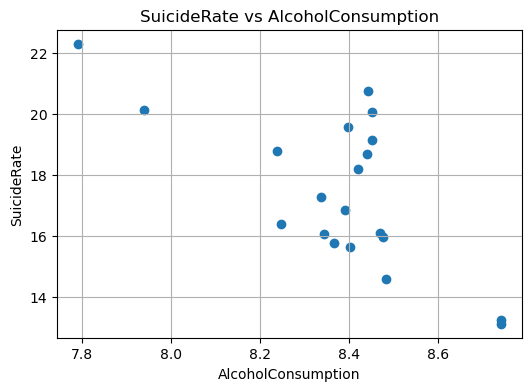

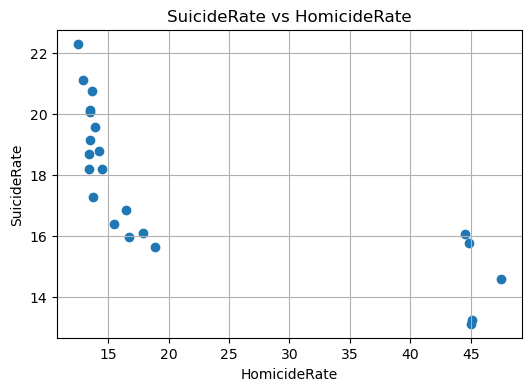

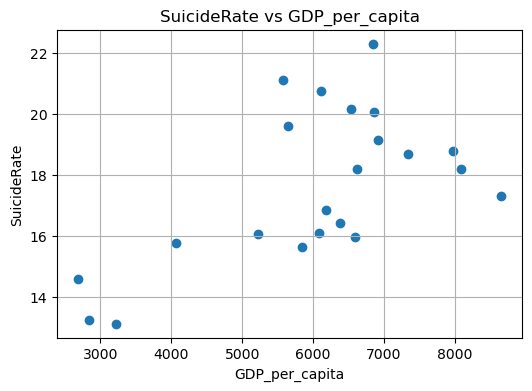

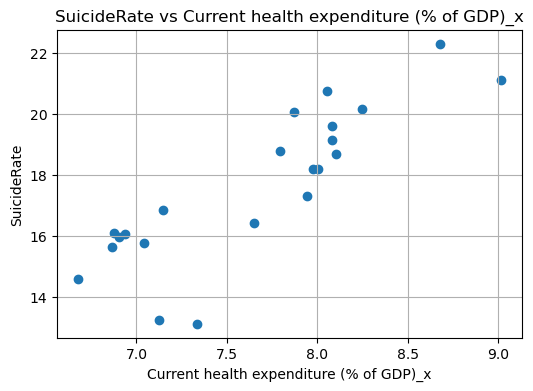

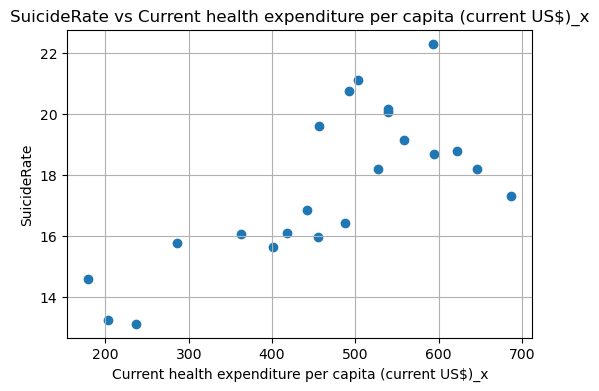

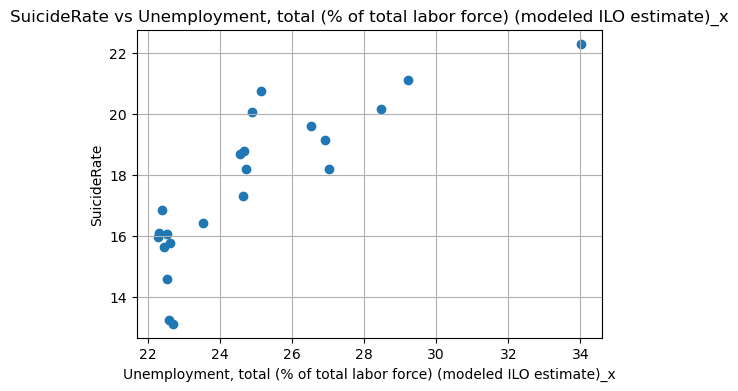

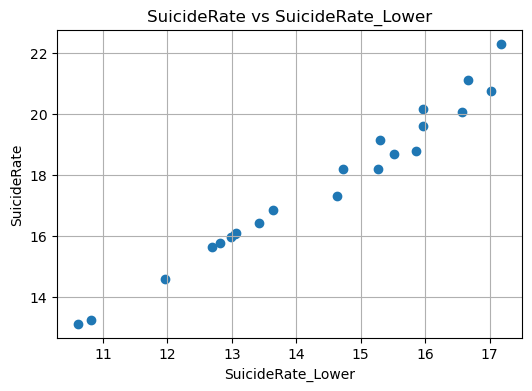

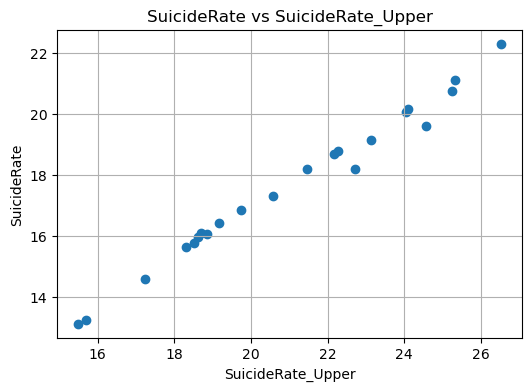

In [11]:
target = "SuicideRate"
predictors = [c for c in numeric_cols if c not in ["Year", target]]

for p in predictors:
    plt.figure(figsize=(6,4))
    plt.scatter(df[p], df[target])
    plt.title(f"{target} vs {p}")
    plt.xlabel(p)
    plt.ylabel(target)
    plt.grid(True)
    plt.show()

In [12]:
corr = df[numeric_cols].corr()
corr

,Year,AlcoholConsumption,HomicideRate,GDP_per_capita,Current health expenditure (% of GDP)_x,Current health expenditure per capita (current US$)_x,"Unemployment, total (% of total labor force) (modeled ILO estimate)_x",SuicideRate,SuicideRate_Lower,SuicideRate_Upper
Year,1.000000,-0.726575,-0.790222,0.592786,0.908857,0.744777,0.902579,0.941972,0.913488,0.952687
AlcoholConsumption,-0.726575,1.000000,0.461433,-0.438754,-0.639478,-0.532635,-0.827699,-0.686743,-0.621078,-0.643844
HomicideRate,-0.790222,0.461433,1.000000,-0.854606,-0.637663,-0.875429,-0.501250,-0.749076,-0.775920,-0.735884
GDP_per_capita,0.592786,-0.438754,-0.854606,1.000000,0.489130,0.968343,0.325214,0.608787,0.678631,0.576563
Current health expenditure (% of GDP)_x,0.908857,-0.639478,-0.637663,0.489130,1.000000,0.687546,0.867541,0.849754,0.832253,0.858785
Current health expenditure per capita (current US$)_x,0.744777,-0.532635,-0.875429,0.968343,0.687546,1.000000,0.518078,0.733916,0.789896,0.708844
"Unemployment, total (% of total labor force) (modeled ILO estimate)_x",0.902579,-0.827699,-0.501250,0.325214,0.867541,0.518078,1.000000,0.820128,0.741898,0.823531
SuicideRate,0.941972,-0.686743,-0.749076,0.608787,0.849754,0.733916,0.820128,1.000000,0.985582,0.992580
SuicideRate_Lower,0.913488,-0.621078,-0.775920,0.678631,0.832253,0.789896,0.741898,0.985582,1.000000,0.979701
SuicideRate_Upper,0.952687,-0.643844,-0.735884,0.576563,0.858785,0.708844,0.823531,0.992580,0.979701,1.000000


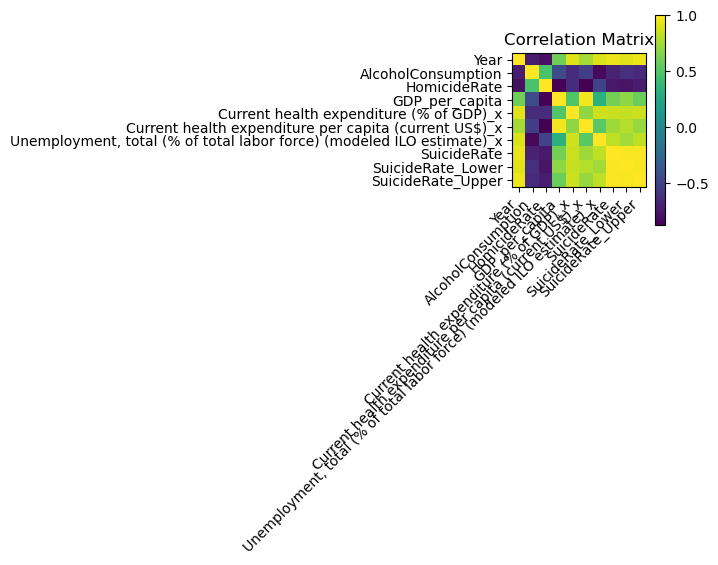

In [13]:
plt.figure(figsize=(7,6))
plt.imshow(corr, interpolation='nearest')
plt.colorbar()
plt.xticks(range(len(numeric_cols)), numeric_cols, rotation=45, ha="right")
plt.yticks(range(len(numeric_cols)), numeric_cols)
plt.title("Correlation Matrix")
plt.tight_layout()
plt.show()

In [14]:
df = df.sort_values("Year")

In [15]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()

df_interpolated = df.copy()
df_interpolated[numeric_cols] = df_interpolated[numeric_cols].interpolate(
    method='linear',
    limit_direction='both'
)

In [16]:
df_interpolated.isna().sum()

Year                                                                     0
AlcoholConsumption                                                       0
HomicideRate                                                             0
GDP_per_capita                                                           0
Current health expenditure (% of GDP)_x                                  0
Current health expenditure per capita (current US$)_x                    0
Unemployment, total (% of total labor force) (modeled ILO estimate)_x    0
SuicideRate                                                              0
SuicideRate_Lower                                                        0
SuicideRate_Upper                                                        0
dtype: int64

In [17]:
df_interpolated

,Year,AlcoholConsumption,HomicideRate,GDP_per_capita,Current health expenditure (% of GDP)_x,Current health expenditure per capita (current US$)_x,"Unemployment, total (% of total labor force) (modeled ILO estimate)_x",SuicideRate,SuicideRate_Lower,SuicideRate_Upper
0,2000,8.742056,45.012212,3217.846934,7.336619,236.081146,22.714,13.132524,10.616174,15.492517
1,2001,8.742056,45.090413,2847.151919,7.123279,202.810654,22.605,13.245669,10.820065,15.693809
2,2002,8.483838,47.472567,2688.236760,6.677745,179.513550,22.547,14.598869,11.962040,17.234773
3,2003,8.366666,44.799503,4062.217560,7.040982,286.019989,22.629,15.759870,12.819716,18.513331
4,2004,8.343871,44.530240,5221.463337,6.938416,362.286621,22.538,16.074981,13.053871,18.851862
5,2005,8.402676,18.905256,5836.876633,6.862162,400.535583,22.461,15.636315,12.685922,18.308753
6,2006,8.470212,17.915438,6077.382934,6.876509,417.911743,22.324,16.099597,13.059278,18.687917
7,2007,8.476132,16.741810,6591.855360,6.905108,455.174988,22.287,15.960853,12.990243,18.628283
8,2008,8.391783,16.464638,6184.754743,7.148323,442.106262,22.407,16.842257,13.632509,19.740628
9,2009,8.248683,15.519685,6374.705600,7.649415,487.627747,23.523,16.407856,13.420787,19.158675


In [19]:
# Step 10.1 — Linear interpolation for missing values
df_model_ready = df_interpolated.copy()

In [20]:
df_model_ready.to_csv("final_model_dataset_2000_onward_EDA_ready.csv", index=False)
